# Notebook 3 — Feature Engineering
This notebook applies the project feature-engineering module to the training split and inspects what new signals are created. We focus on rolling windows, lags, and interaction terms because they help models capture short-term degradation dynamics in time series.

## Imports and data loading
We load the processed training split and call `engineer_features()` from `src.features.feature_engineering`.

The code cell below keeps both original and engineered versions for direct comparison.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.features.feature_engineering import engineer_features

train_path = project_root / "data" / "processed" / "train.csv"

train_df = pd.read_csv(train_path, parse_dates=["timestamp"])
feat_df = engineer_features(train_df.copy())

print("Original shape:", train_df.shape)
print("Engineered shape:", feat_df.shape)

✅ Feature engineering complete. Rows: 859,972 → 859,677 | Features: 99
Original shape: (859972, 9)
Engineered shape: (859677, 99)


## Feature growth
We compare the number of columns before and after engineering.

In [2]:
original_cols = set(train_df.columns)
engineered_cols = list(feat_df.columns)
new_cols = [c for c in engineered_cols if c not in original_cols]

print("Original column count:", len(train_df.columns))
print("Engineered column count:", len(feat_df.columns))
print("New engineered columns:", len(new_cols))
display(pd.DataFrame({"new_feature": new_cols}).head(20))

Original column count: 9
Engineered column count: 99
New engineered columns: 90


,new_feature
0,temperature_roll10_mean
1,temperature_roll10_std
2,temperature_roll10_min
3,temperature_roll10_max
4,vibration_roll10_mean
5,vibration_roll10_std
6,vibration_roll10_min
7,vibration_roll10_max
8,pressure_roll10_mean
9,pressure_roll10_std


## Categorized feature types
We group engineered columns into rolling, lag, diff, interaction, and time-based families.

In [3]:
categories = {
    "rolling": [c for c in new_cols if "roll" in c],
    "lag": [c for c in new_cols if "lag" in c],
    "diff": [c for c in new_cols if "diff" in c],
    "interaction": [c for c in new_cols if any(k in c for k in ["_x_", "ratio", "interaction"])],
    "time-based": [c for c in new_cols if any(k in c for k in ["hour", "day", "month", "weekday"])],
}

for name, cols in categories.items():
    print(f"\n{name.upper()} ({len(cols)}):")
    for c in cols[:25]:
        print(" -", c)
    if len(cols) > 25:
        print(" - ...")


ROLLING (60):
 - temperature_roll10_mean
 - temperature_roll10_std
 - temperature_roll10_min
 - temperature_roll10_max
 - vibration_roll10_mean
 - vibration_roll10_std
 - vibration_roll10_min
 - vibration_roll10_max
 - pressure_roll10_mean
 - pressure_roll10_std
 - pressure_roll10_min
 - pressure_roll10_max
 - rpm_roll10_mean
 - rpm_roll10_std
 - rpm_roll10_min
 - rpm_roll10_max
 - current_roll10_mean
 - current_roll10_std
 - current_roll10_min
 - current_roll10_max
 - temperature_roll30_mean
 - temperature_roll30_std
 - temperature_roll30_min
 - temperature_roll30_max
 - vibration_roll30_mean
 - ...

LAG (20):
 - temperature_lag1
 - vibration_lag1
 - pressure_lag1
 - rpm_lag1
 - current_lag1
 - temperature_lag5
 - vibration_lag5
 - pressure_lag5
 - rpm_lag5
 - current_lag5
 - temperature_lag10
 - vibration_lag10
 - pressure_lag10
 - rpm_lag10
 - current_lag10
 - temperature_lag30
 - vibration_lag30
 - pressure_lag30
 - rpm_lag30
 - current_lag30

DIFF (5):
 - temperature_diff1
 - vib

## Rolling mean vs raw signal
Rolling features smooth noise and expose trend behavior. We compare raw temperature with a rolling mean over 500 rows.

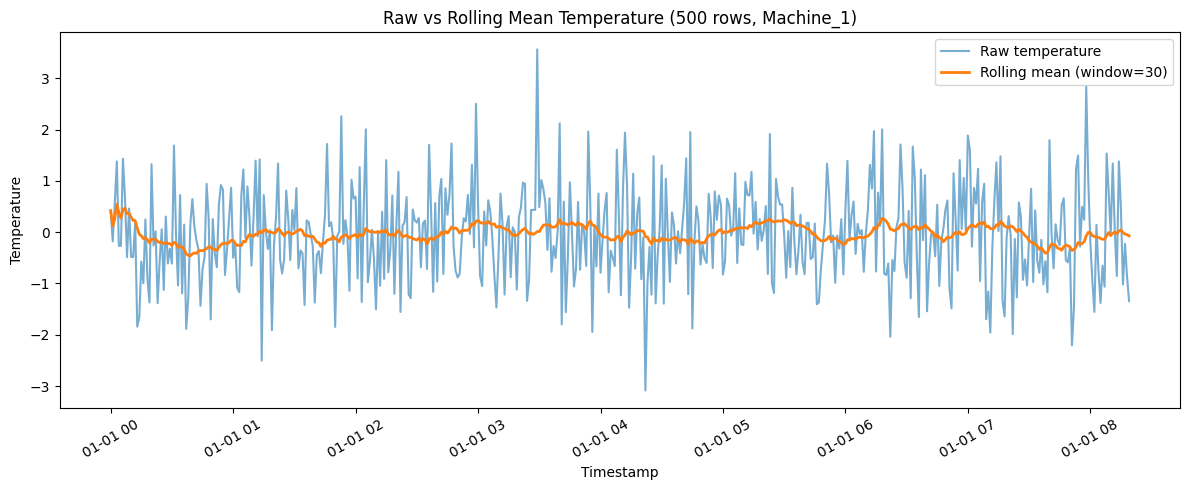

In [4]:
sample = train_df[train_df["machine_id"] == "Machine_1"].copy().sort_values("timestamp").head(500)
sample["temperature_roll30_mean"] = sample["temperature"].rolling(30, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(sample["timestamp"], sample["temperature"], label="Raw temperature", alpha=0.6)
plt.plot(sample["timestamp"], sample["temperature_roll30_mean"], label="Rolling mean (window=30)", linewidth=2)
plt.title("Raw vs Rolling Mean Temperature (500 rows, Machine_1)")
plt.xlabel("Timestamp")
plt.ylabel("Temperature")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Feature engineering is validated and ready for model training in Notebook 4.